<a href="https://colab.research.google.com/github/tatyanakrivonogova/machine-learning-methods/blob/master/%D0%91%D0%BB%D0%BE%D0%BA_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Метод главных компонент (PCA)
Метод главных компонент (PCA) – техника снижения размерности, которая линейно преобразует исходные признаки в новое пространство меньшей размерности, максимизируя дисперсию данных.

### Используемые библиотеки

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

### Датасет

In [169]:
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print("Размер:", X.shape)
print("Целевые классы:", target_names)
print("\nПервые 5 строк данных:\n", pd.DataFrame(X, columns=feature_names).head())

Размер: (178, 13)
Целевые классы: ['class_0' 'class_1' 'class_2']

Первые 5 строк данных:
    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.8

### Предварительная обработка датасета

In [170]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Тепловая карта

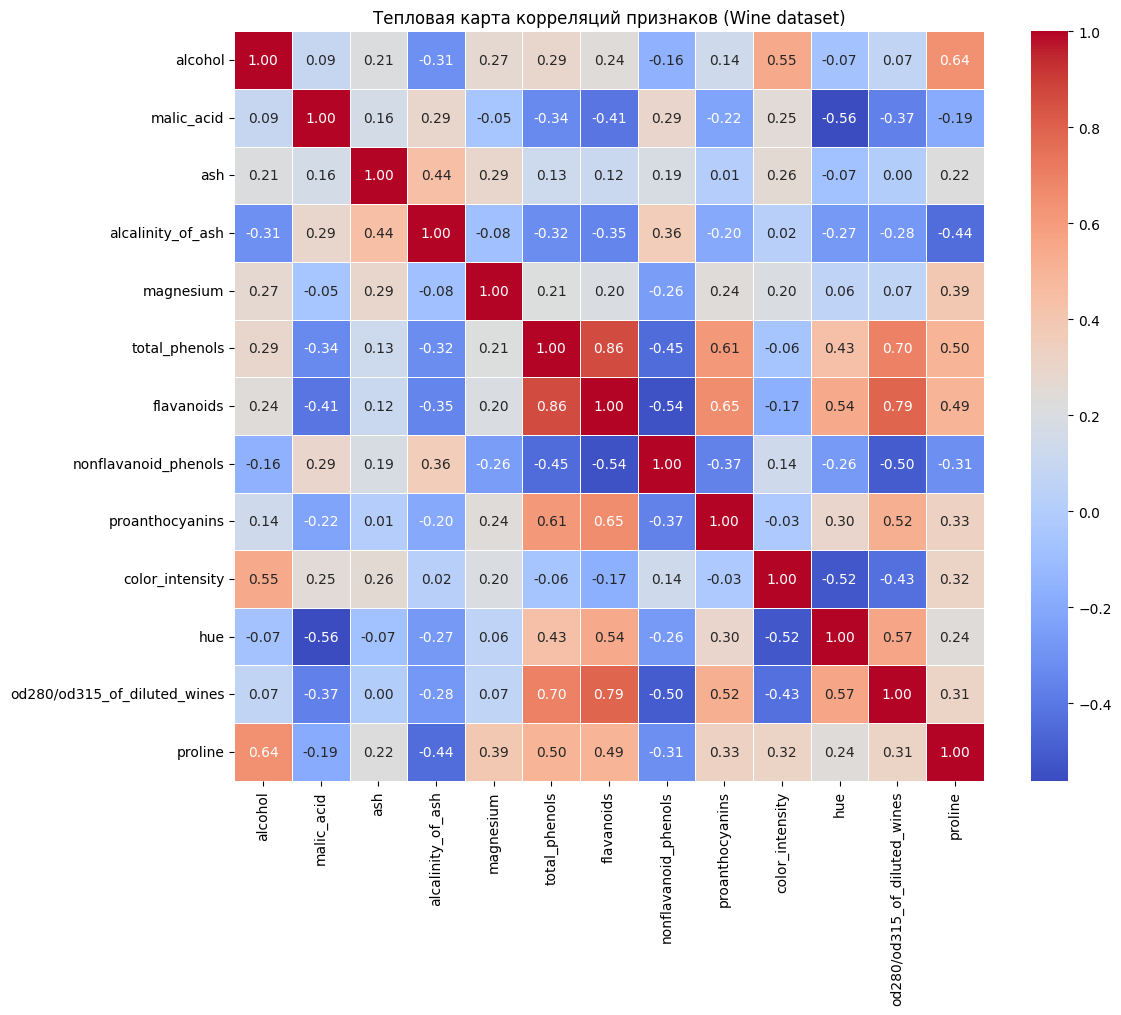

In [171]:
plt.figure(figsize=(12, 10))
corr_matrix = np.corrcoef(X_scaled.T)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            xticklabels=feature_names, yticklabels=feature_names,
            square=True, linewidths=0.5)
plt.title('Тепловая карта корреляций признаков (Wine dataset)')
plt.tight_layout()
plt.show()

### Обучение модели

In [172]:
pca = PCA(n_components=2)
pca.fit(X_scaled)

PCA(n_components=2)

### Прогнозы модели

In [173]:
X_pca = pca.transform(X_scaled)
print("Размерность после PCA:", X_pca.shape)
print("\nПервые 5 образцов в пространстве главных компонент:\n", X_pca[:5])

Размерность после PCA: (178, 2)

Первые 5 образцов в пространстве главных компонент:
 [[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 [ 3.75706561  2.75637191]
 [ 1.00890849  0.86983082]]


### Графики выходных результатов

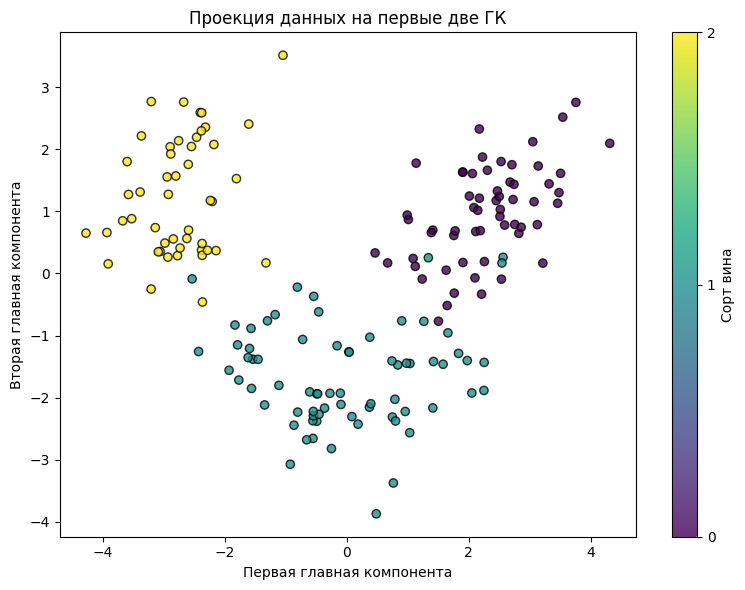

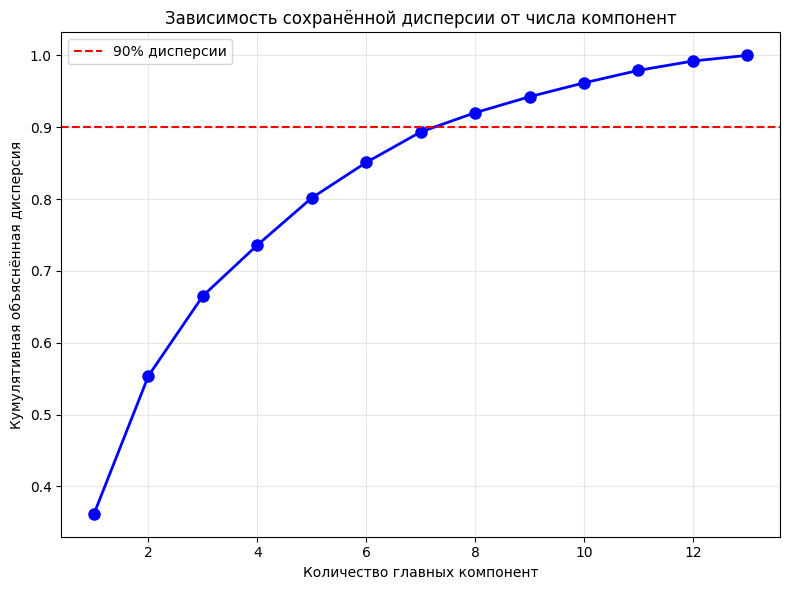

In [174]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.8)
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Проекция данных на первые две ГК')
plt.colorbar(scatter, ticks=range(len(target_names)), label='Сорт вина')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.9, color='r', linestyle='--', label='90% дисперсии')
plt.xlabel('Количество главных компонент')
plt.ylabel('Кумулятивная объяснённая дисперсия')
plt.title('Зависимость сохранённой дисперсии от числа компонент')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Исходные признаки
Accuracy:  0.7407
Precision: 0.7409
Recall:    0.7407
F1-score:  0.7361
              precision    recall  f1-score   support

     class_0       0.69      0.61      0.65        18
     class_1       0.79      0.71      0.75        21
     class_2       0.74      0.93      0.82        15

    accuracy                           0.74        54
   macro avg       0.74      0.75      0.74        54
weighted avg       0.74      0.74      0.74        54


PCA (n_components=2, объяснённая дисперсия=0.549)
Accuracy:  0.9074
Precision: 0.9110
Recall:    0.9074
F1-score:  0.9061
              precision    recall  f1-score   support

     class_0       0.85      0.94      0.89        18
     class_1       0.94      0.81      0.87        21
     class_2       0.94      1.00      0.97        15

    accuracy                           0.91        54
   macro avg       0.91      0.92      0.91        54
weighted avg       0.91      0.91      0.91        54


PCA (n_components=8, об

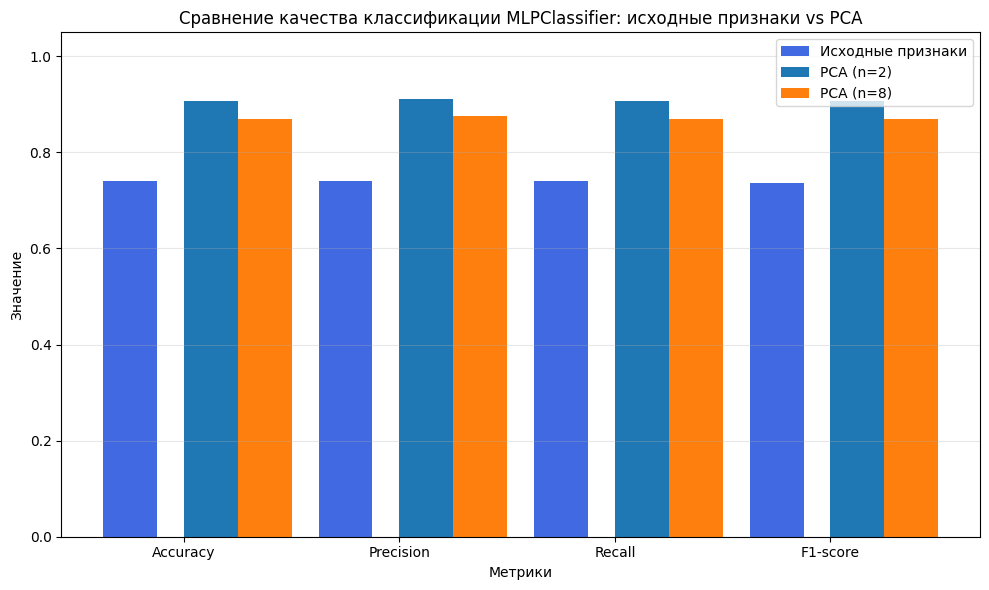

In [175]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def evaluate_mlp(X_train_data, X_test_data, y_train_data, y_test_data, description):
    mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42, early_stopping=True)
    mlp.fit(X_train_data, y_train_data)
    y_pred = mlp.predict(X_test_data)

    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, average='weighted')
    rec = recall_score(y_test_data, y_pred, average='weighted')
    f1 = f1_score(y_test_data, y_pred, average='weighted')

    print(f"\n{description}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(classification_report(y_test_data, y_pred, target_names=target_names))

    return acc, prec, rec, f1

# Оценка на исходных (масштабированных) признаках
orig_metrics = evaluate_mlp(X_train_scaled, X_test_scaled, y_train, y_test,
                            "Исходные признаки")

# Оценка для двух вариантов: 2 компоненты и оптимальное для 90% дисперсии - 8 компонент
components_list = [2, 8]
results = {}

for n_comp in components_list:
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    explained_var = pca.explained_variance_ratio_.sum()
    metrics = evaluate_mlp(X_train_pca, X_test_pca, y_train, y_test,
                           f"PCA (n_components={n_comp}, объяснённая дисперсия={explained_var:.3f})")
    results[n_comp] = {'metrics': metrics, 'explained_var': explained_var}

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
orig_vals = orig_metrics
x = np.arange(len(metrics_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, orig_vals, width, label='Исходные признаки', color='royalblue')

for i, (n_comp, data) in enumerate(results.items()):
    comp_vals = data['metrics']
    offset = (i + 1) * width - width/2
    plt.bar(x + offset, comp_vals, width, label=f'PCA (n={n_comp})')

plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение качества классификации MLPClassifier: исходные признаки vs PCA')
plt.xticks(x, metrics_names)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Нейронная сеть прямого распространения (классификация)
Многослойный перцептрон представляет собой нейронную сеть прямого распространения, состоящую из входного слоя, одного или нескольких скрытых слоёв и выходного слоя. Обучение выполняется методом обратного распространения ошибки с использованием оптимизатора на основе градиентного спуска.

### Используемые библиотеки

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import GridSearchCV

### Датасет

In [177]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print("Название датасета: Breast Cancer Wisconsin (Diagnostic)")
print("Количество образцов:", X.shape)
print("Классы:", target_names)
print("Распределение классов:\n", pd.Series(y).value_counts())
print("\nПервые 5 строк:")
print(pd.DataFrame(X, columns=feature_names).head())

Название датасета: Breast Cancer Wisconsin (Diagnostic)
Количество образцов: (569, 30)
Классы: ['malignant' 'benign']
Распределение классов:
 1    357
0    212
Name: count, dtype: int64

Первые 5 строк:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414     

### Предварительная обработка датасета

In [178]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Размер обучающей выборки:", X_train_scaled.shape)
print("Размер тестовой выборки:", X_test_scaled.shape)

Размер обучающей выборки: (455, 30)
Размер тестовой выборки: (114, 30)


### Тепловая карта

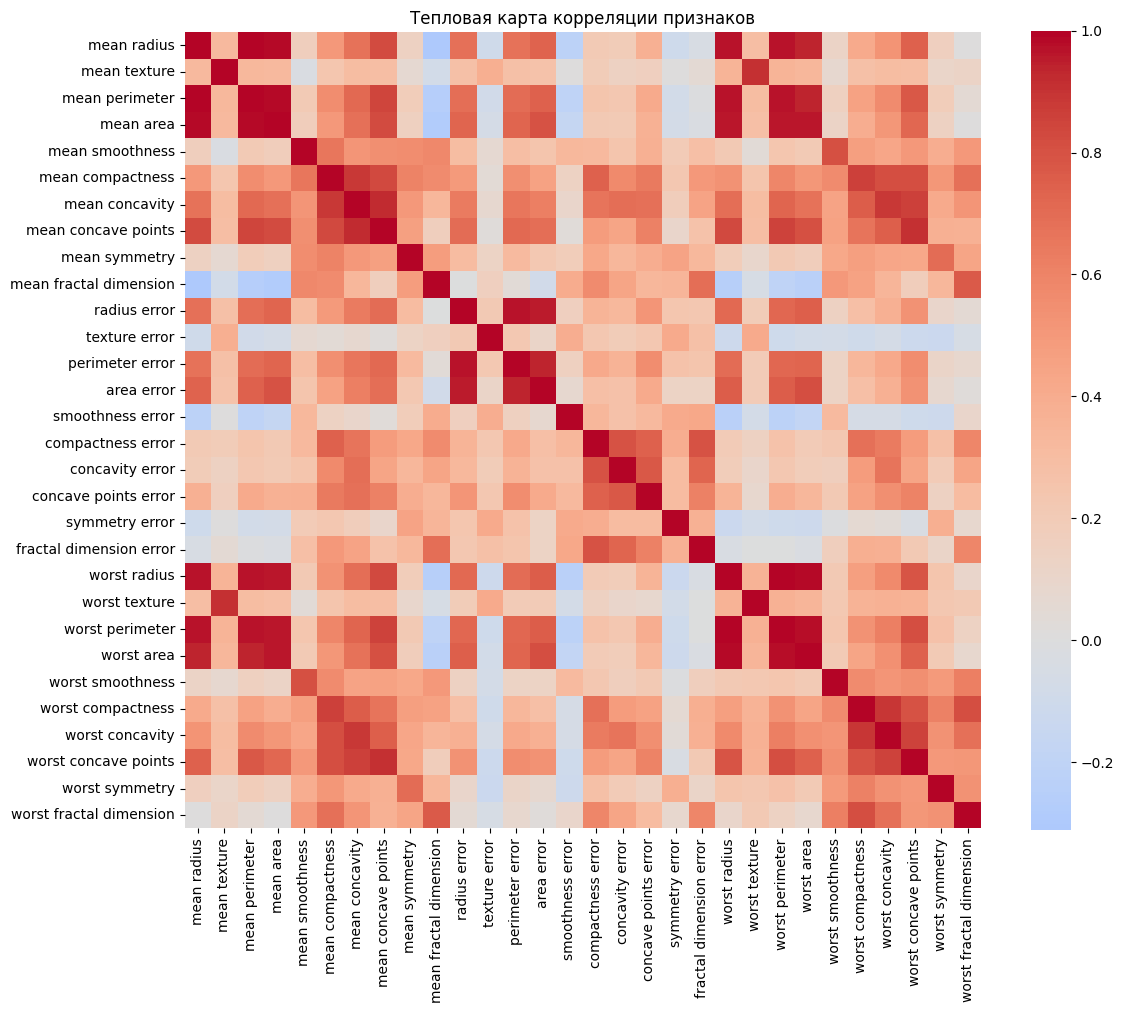

In [179]:
df_features = pd.DataFrame(X, columns=feature_names)
plt.figure(figsize=(12, 10))
sns.heatmap(df_features.corr(), cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Тепловая карта корреляции признаков')
plt.tight_layout()
plt.show()

### Обучение модели

In [180]:
# mlp = MLPClassifier(random_state=42, max_iter=200, verbose=False)

# # Сетка гиперпараметров для перебора
# param_grid = {
#     'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],   # размеры слоёв
#     'activation': ['relu', 'tanh', 'logistic'],                   # функции активации
#     'solver': ['adam', 'sgd'],                                    # оптимизаторы
#     'alpha': [0.0001, 0.001, 0.01],                               # коэффициент регуляризации
#     'learning_rate_init': [0.001, 0.01],                          # начальная скорость обучения (для sgd)
#     'max_iter': [200, 300]                                        # максимальное число итераций
# }

# # Создание объекта GridSearchCV
# grid_search = GridSearchCV(
#     estimator=mlp,
#     param_grid=param_grid,
#     cv=5,                # 5-кратная кросс-валидация
#     scoring='accuracy',  # метрика качества (можно изменить)
#     n_jobs=-1,           # использовать все доступные ядра
#     verbose=1
# )

# # Запуск подбора
# grid_search.fit(X_train_scaled, y_train)

# # Вывод лучших параметров и лучшей оценки
# print("Лучшие параметры:", grid_search.best_params_)
# print("Лучшая точность на кросс-валидации: {:.3f}".format(grid_search.best_score_))

In [181]:
mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='logistic',
    alpha=0.0001,
    solver='sgd',
    learning_rate_init=0.01,
    max_iter=200,
    random_state=42,
    verbose=False
)
mlp.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(activation='logistic', hidden_layer_sizes=(50,),
              learning_rate_init=0.01, random_state=42, solver='sgd')

### Прогнозы модели

In [182]:
y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)  # вычисляем полноту

print("Точность на тестовой выборке: {:.2f}%".format(accuracy * 100))
print("Полнота на тестовой выборке: {:.2f}%".format(recall * 100))

Точность на тестовой выборке: 97.37%
Полнота на тестовой выборке: 97.22%


### Графики выходных результатов

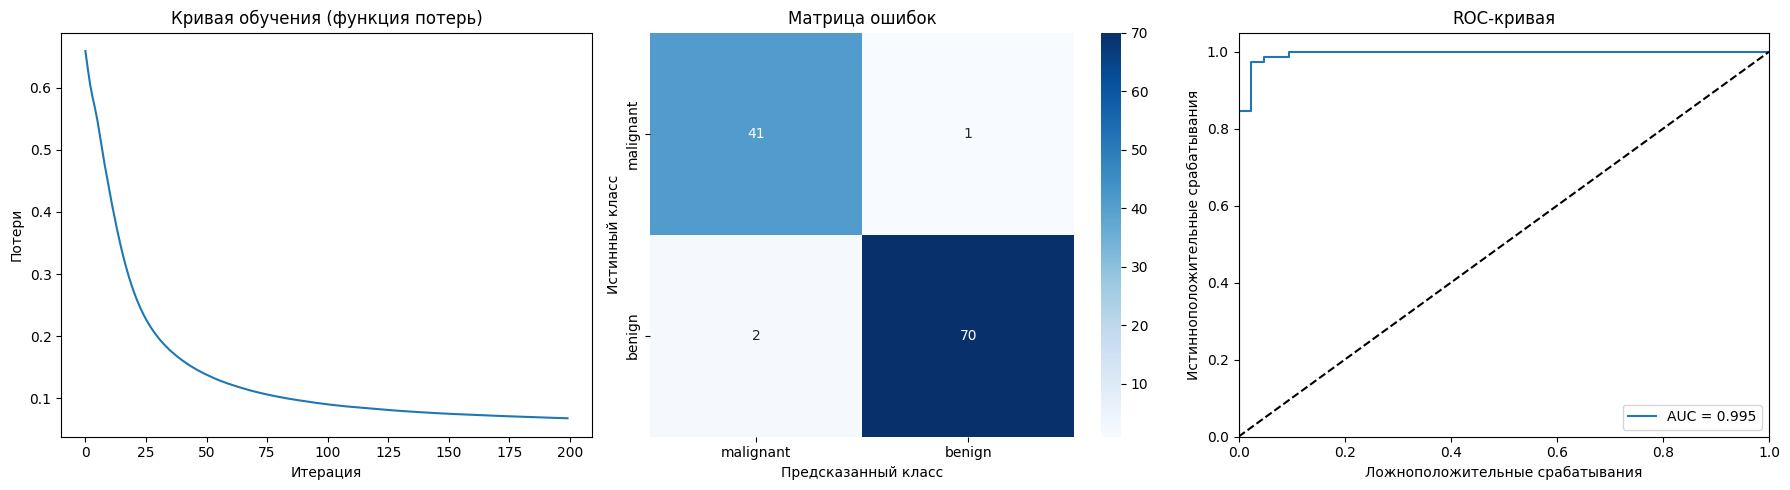

In [183]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График функции потерь
axes[0].plot(mlp.loss_curve_)
axes[0].set_title('Кривая обучения (функция потерь)')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Потери')

# Тепловая карта матрицы ошибок
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Матрица ошибок')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

# ROC-кривая
y_proba = mlp.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Ложноположительные срабатывания')
axes[2].set_ylabel('Истинноположительные срабатывания')
axes[2].set_title('ROC-кривая')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Нейронная сеть прямого распространения (регрессия)
Модель - многослойный перцептрон, состоящий из последовательно соединённых полносвязных слоёв. Обучение выполняется с использованием алгоритма обратного распространения ошибки и оптимизатора Adam. Сеть аппроксимирует нелинейную зависимость между входными признаками и непрерывной целевой переменной, минимизируя среднеквадратичную ошибку (MSE).

### Используемые библиотеки

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor

### Датасет

In [185]:
data = fetch_california_housing()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['MedHouseVal'] = y

print("Размер:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

Размер: (20640, 9)

Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


### Предварительная обработка датасета

In [186]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Размер обучающей выборки:", X_train_scaled.shape)
print("Размер тестовой выборки:", X_test_scaled.shape)

Размер обучающей выборки: (16512, 8)
Размер тестовой выборки: (4128, 8)


### Тепловая карта

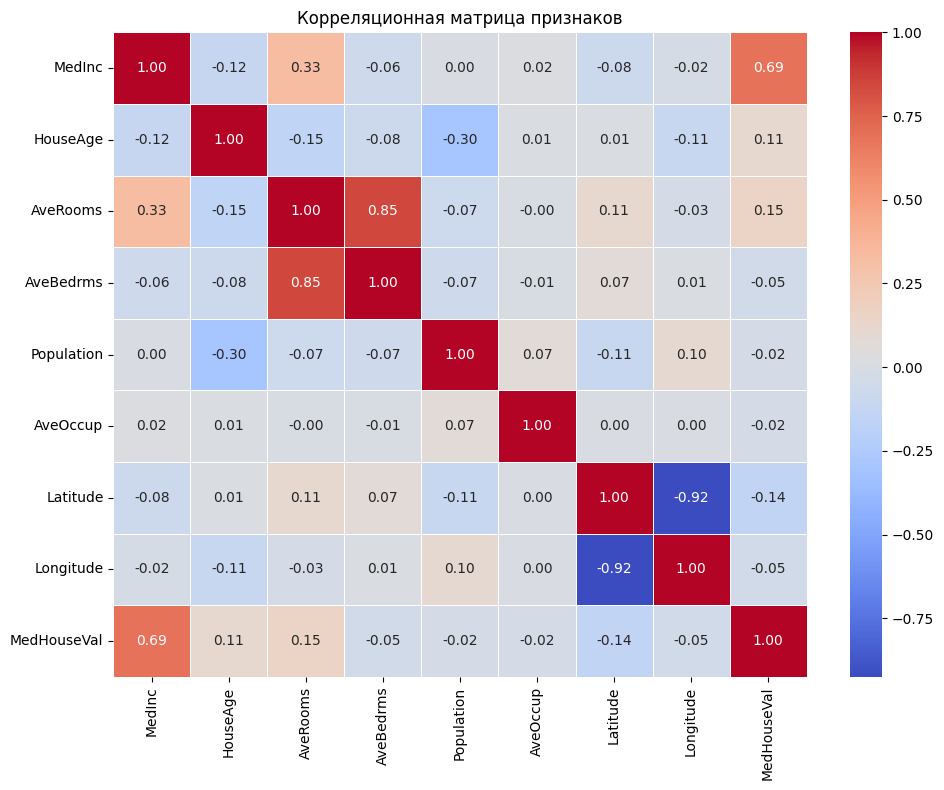

In [187]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

### Обучение модели

In [188]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import uniform, randint

# mlp = MLPRegressor(
#     random_state=42,
#     max_iter=100,
#     early_stopping=True,
#     validation_fraction=0.1,
#     verbose=False
# )

# param_dist = {
#     'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (64, 32, 16)],
#     'activation': ['relu', 'tanh', 'logistic'],
#     'solver': ['adam', 'sgd'],
#     'alpha': uniform(1e-5, 1e-2),
#     'learning_rate_init': uniform(1e-4, 1e-2),
#     'batch_size': randint(16, 128),
#     'learning_rate': ['constant', 'adaptive']
# }

# random_search = RandomizedSearchCV(
#     estimator=mlp,
#     param_distributions=param_dist,
#     n_iter=50,
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# random_search.fit(X_train_scaled, y_train)

# print("Лучшие параметры:", random_search.best_params_)
# print("Лучшее значение MSE на кросс-валидации:", -random_search.best_score_)

In [189]:
model = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation='tanh',
    solver='adam',
    alpha=0.0038,
    batch_size=105,
    learning_rate_init=0.0069,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)

model.fit(X_train_scaled, y_train)

MLPRegressor(activation='tanh', alpha=0.0038, batch_size=105,
             early_stopping=True, hidden_layer_sizes=(64, 32, 16),
             learning_rate_init=0.0069, random_state=42,
             validation_fraction=0.2)

### Прогнозы модели

In [190]:
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")

MSE: 0.2631
MAE: 0.3449
R2: 0.7992


### Графики выходных результатов

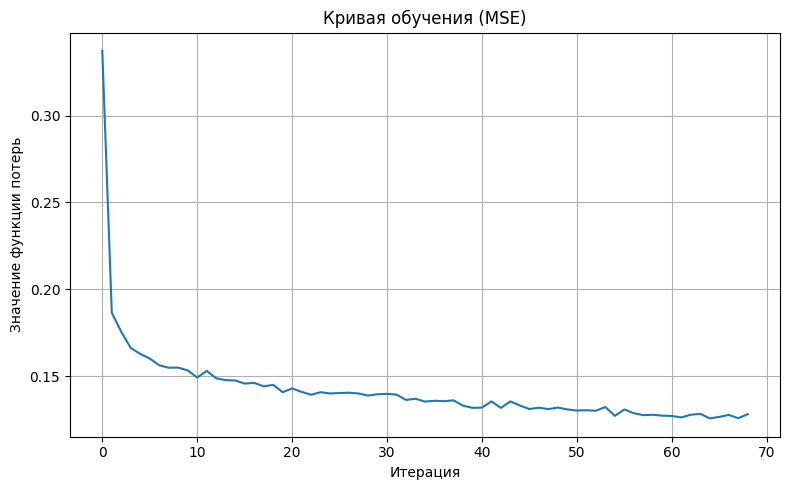

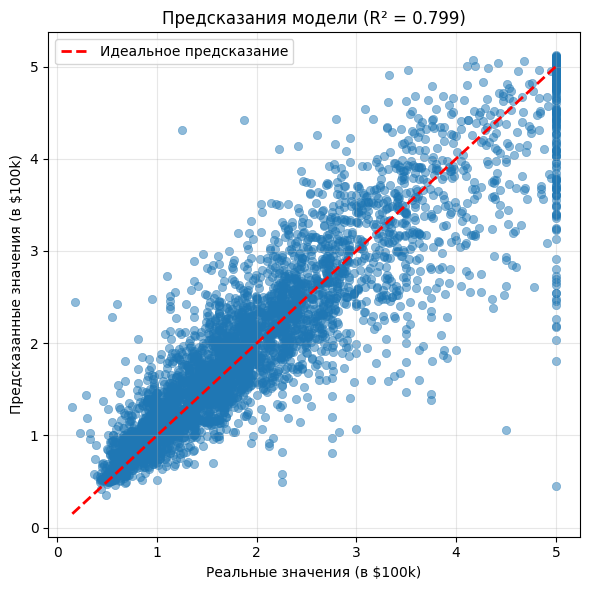

In [191]:
train_loss = model.loss_curve_
plt.figure(figsize=(8, 5))
plt.plot(train_loss)
plt.xlabel('Итерация')
plt.ylabel('Значение функции потерь')
plt.title('Кривая обучения (MSE)')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, edgecolor=None)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Реальные значения (в $100k)')
plt.ylabel('Предсказанные значения (в $100k)')
plt.title(f'Предсказания модели (R² = {r2:.3f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()